# Regression by Minimizing Absolute Deviation — Complete Workflow

This notebook reproduces the repository workflow from data loading to final validation.

**Empirical datasets:** Boston Housing, Concrete Compressive Strength, Hawkins–Bradu–Kass (HBK).

**Core literature:** Wagner (1959), Barrodale & Roberts (1973), Bassett & Koenker (1978), Bloomfield & Steiger (1980), Narula & Wellington (1982), and Pollard (1991).

## Objective

> How does regression obtained by minimizing absolute deviations differ from regression obtained by minimizing squared deviations, particularly when observations contain large or extreme errors?


## 1. Mathematical formulation

For observation \(i\),

$$
r_i = y_i - x_i^T\beta.
$$

Ordinary Least Squares minimizes

$$
\min_{\beta}\sum_{i=1}^{n} r_i^2.
$$

Least Absolute Deviations minimizes

$$
\min_{\beta}\sum_{i=1}^{n}|r_i|.
$$

For the linear-programming form of LAD,

$$
r_i=e_i^+-e_i^-,
\qquad
e_i^+\ge 0,\quad e_i^-\ge 0,
$$

and the objective is

$$
\min \sum_{i=1}^{n}\left(e_i^+ + e_i^-\right).
$$


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Image, display

from absolute_deviation.data import DATASETS, load_dataset
from absolute_deviation.experiments import (
    RESULT_DIR,
    FIGURE_DIR,
    run_original_data,
    run_contamination_experiment,
    run_error_distribution_experiment,
    run_runtime_benchmark,
    validate_lad_solver,
)
from absolute_deviation.models import fit_ols, fit_lad
from absolute_deviation.plotting import (
    plot_clean_and_contaminated_lines,
    plot_contamination_results,
    plot_distribution_results,
    plot_runtime_results,
    plot_real_dataset_predictions,
    plot_hbk_multivariate_inlier_outlier,
    plot_unlabeled_multivariate_residual_space,
)

pd.set_option("display.max_columns", 50)
ROOT

PosixPath('/home/runner/work/Absolute_Deviation_vs_Squarred_Error/Absolute_Deviation_vs_Squarred_Error')

## 2. Load and inspect the empirical datasets

In [2]:
dataset_rows = []
for name in DATASETS:
    X, y, columns = load_dataset(name)
    dataset_rows.append({
        "dataset": name,
        "observations": len(y),
        "predictors": X.shape[1],
        "target": DATASETS[name]["target"],
        "predictor_names": ", ".join(columns),
    })

dataset_summary = pd.DataFrame(dataset_rows)
display(dataset_summary)

,dataset,observations,predictors,target,predictor_names
0,boston_housing,506,12,MEDV,"CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD,..."
1,concrete_strength,1030,8,Strength,"Cement, BlastFurnaceSlag, FlyAsh, Water, Super..."
2,hbk,75,3,Y,"X1, X2, X3"


## 3. Fit OLS and LAD on the original datasets

The same rows and predictors are used for both models. OLS minimizes SSE and LAD minimizes SAE on the fitted sample.


In [3]:
original_metrics, original_coefficients = run_original_data()
display(original_metrics)
display(original_coefficients.head(20))

,dataset,model,SSE,SAE,MAE,RMSE,runtime_seconds
0,boston_housing,OLS,11349.418808,1698.290859,3.356306,4.735998,0.000323
1,boston_housing,LAD,12469.793173,1611.011000,3.183816,4.964258,0.031135
2,concrete_strength,OLS,110428.156817,8461.346375,8.214899,10.354313,0.000178
3,concrete_strength,LAD,119464.579642,8289.485903,8.048045,10.769635,0.081982
4,hbk,OLS,359.485726,103.468960,1.379586,2.189325,0.000085
5,hbk,LAD,587.732546,86.742870,1.156572,2.799363,0.002633


,dataset,model,term,estimate
0,boston_housing,OLS,Intercept,41.617270
1,boston_housing,OLS,CRIM,-0.121389
2,boston_housing,OLS,ZN,0.046963
3,boston_housing,OLS,INDUS,0.013468
4,boston_housing,OLS,CHAS,2.839993
5,boston_housing,OLS,NOX,-18.758022
6,boston_housing,OLS,RM,3.658119
7,boston_housing,OLS,AGE,0.003611
8,boston_housing,OLS,DIS,-1.490754
9,boston_housing,OLS,RAD,0.289405


## 4. Empirical multivariate visualizations

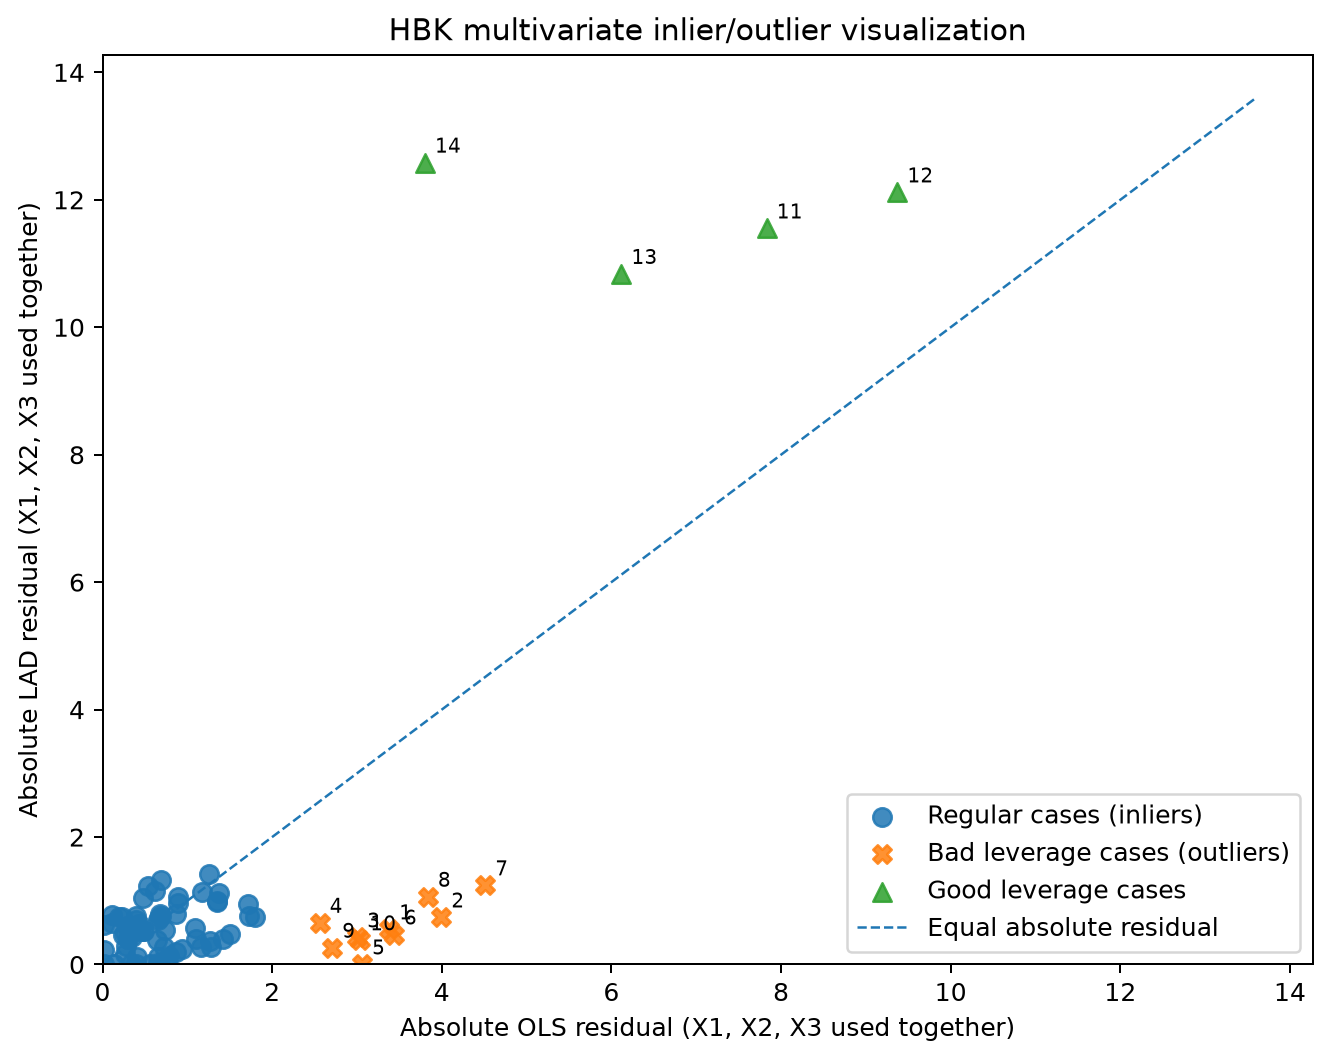

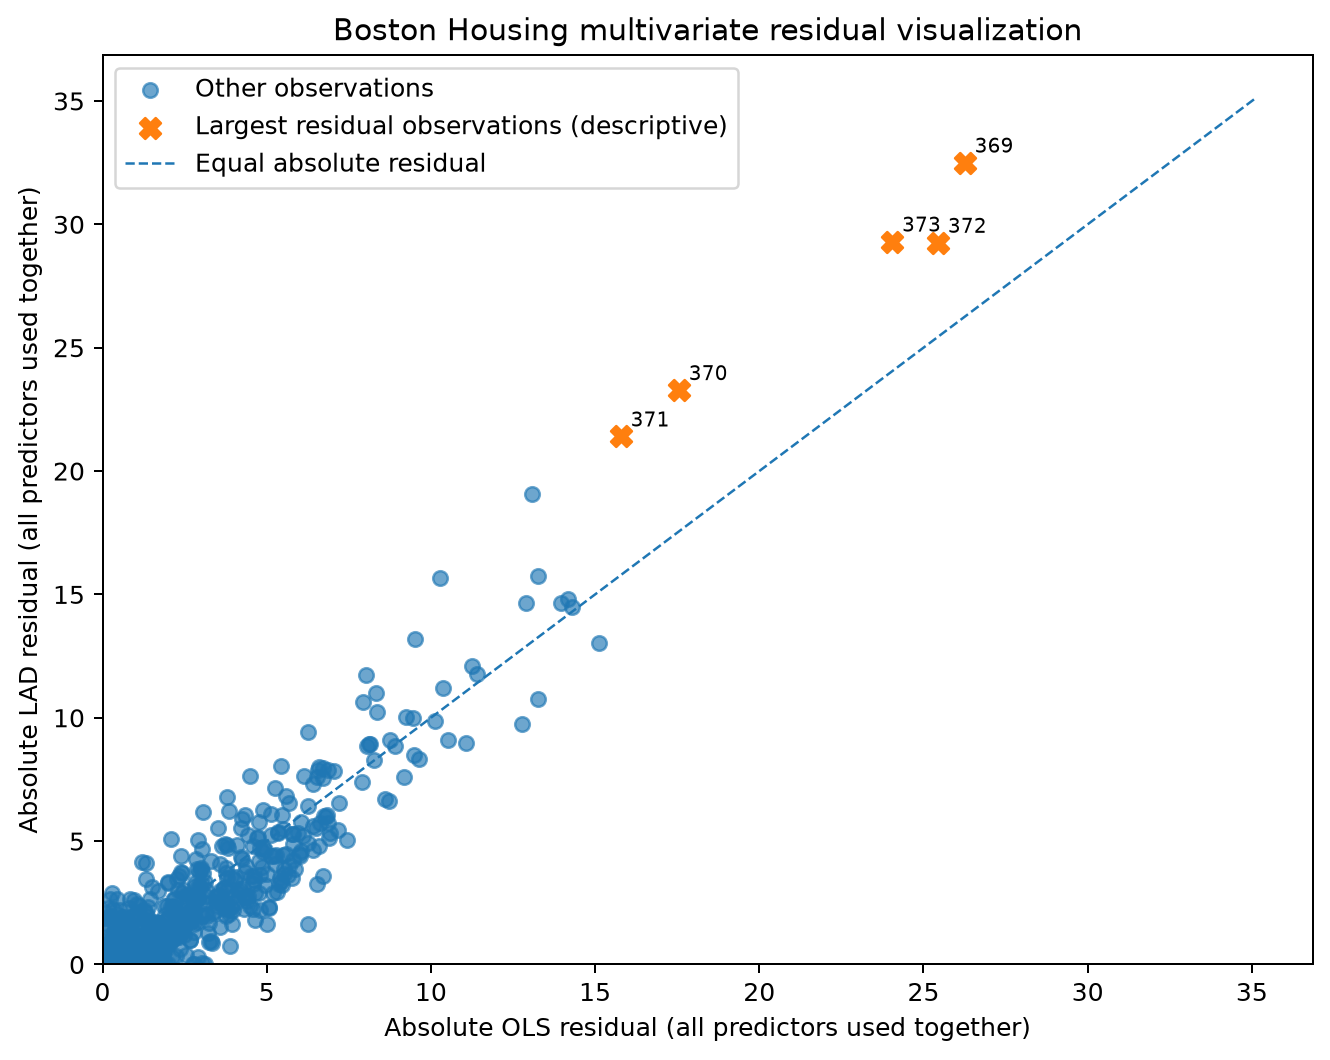

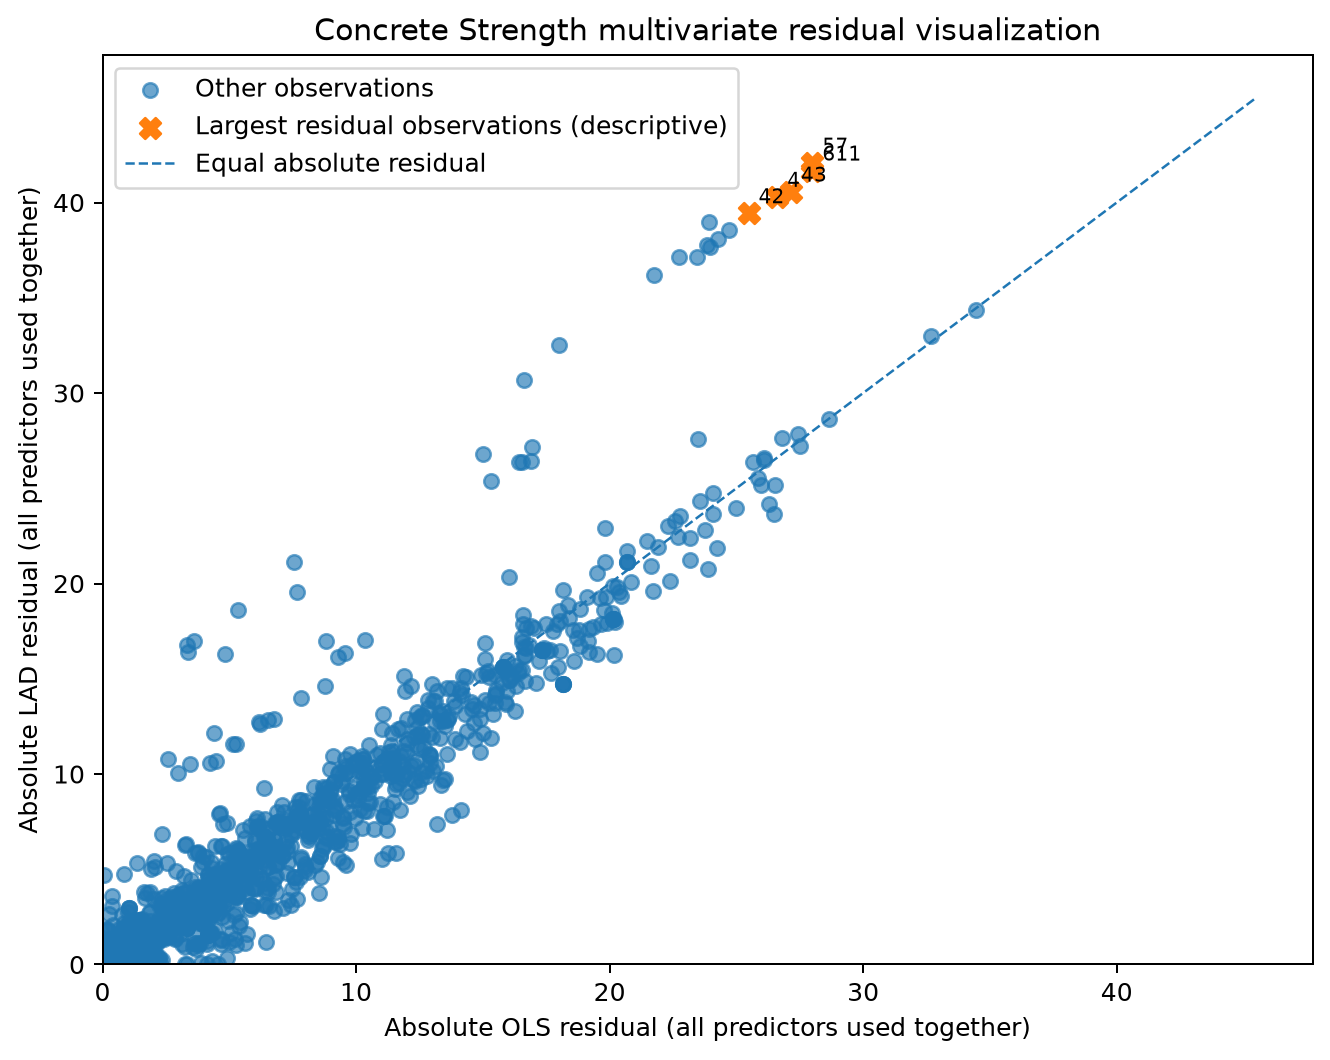

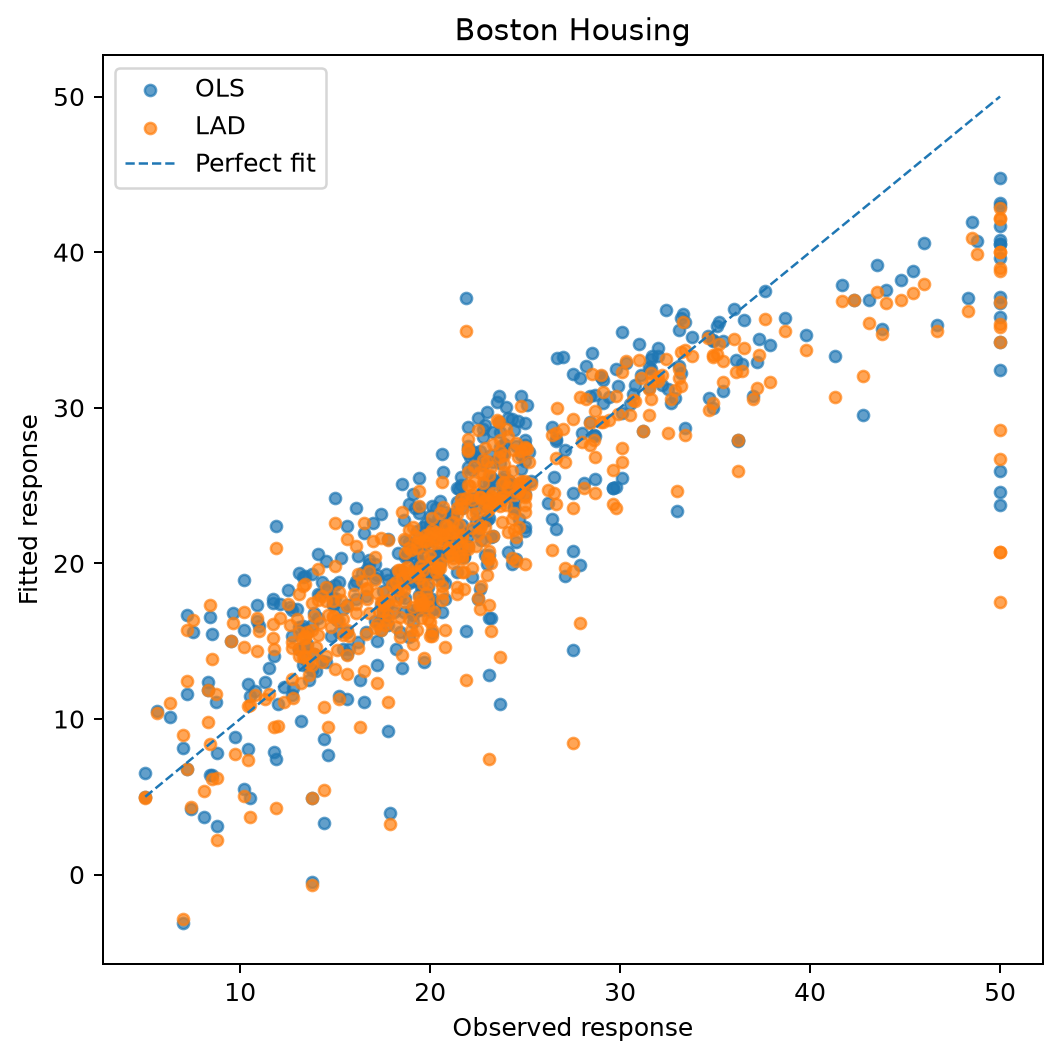

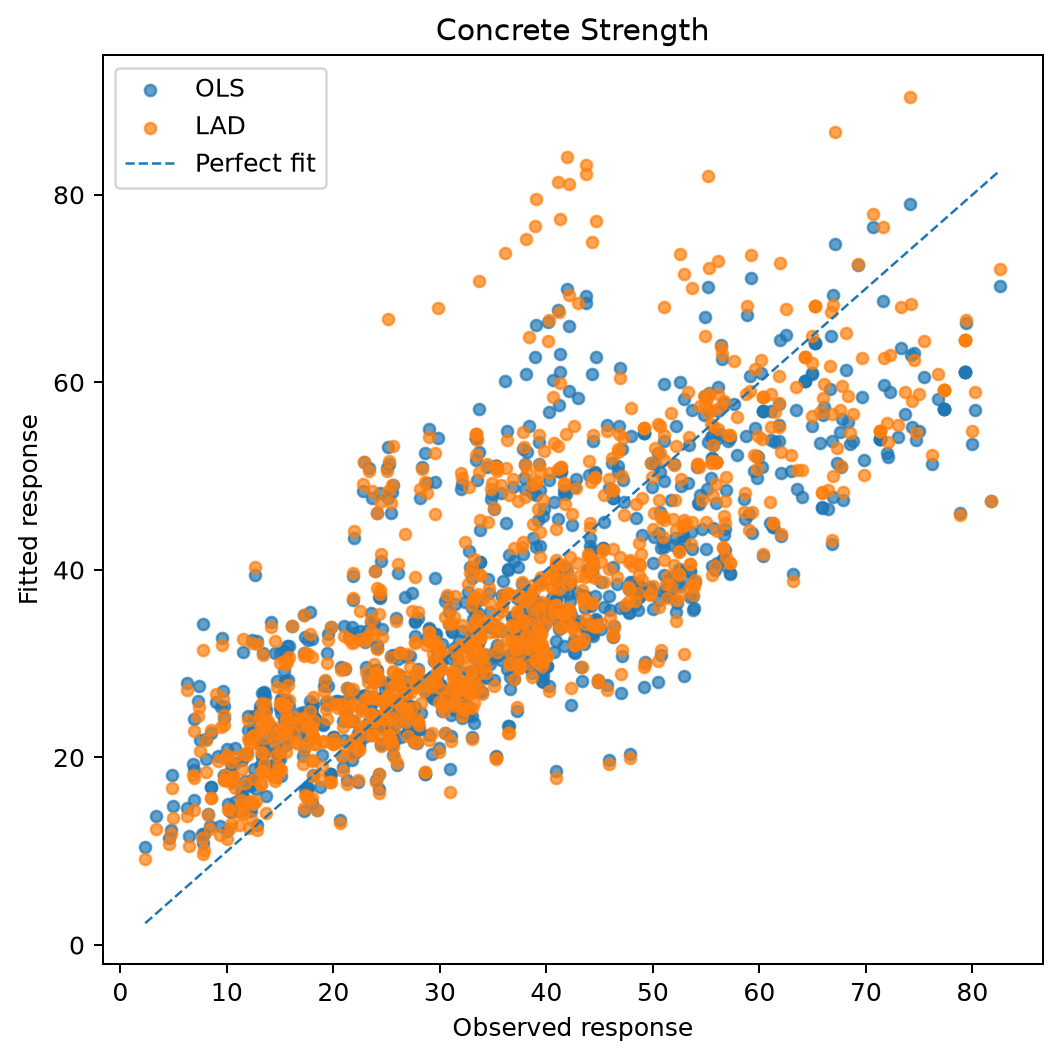

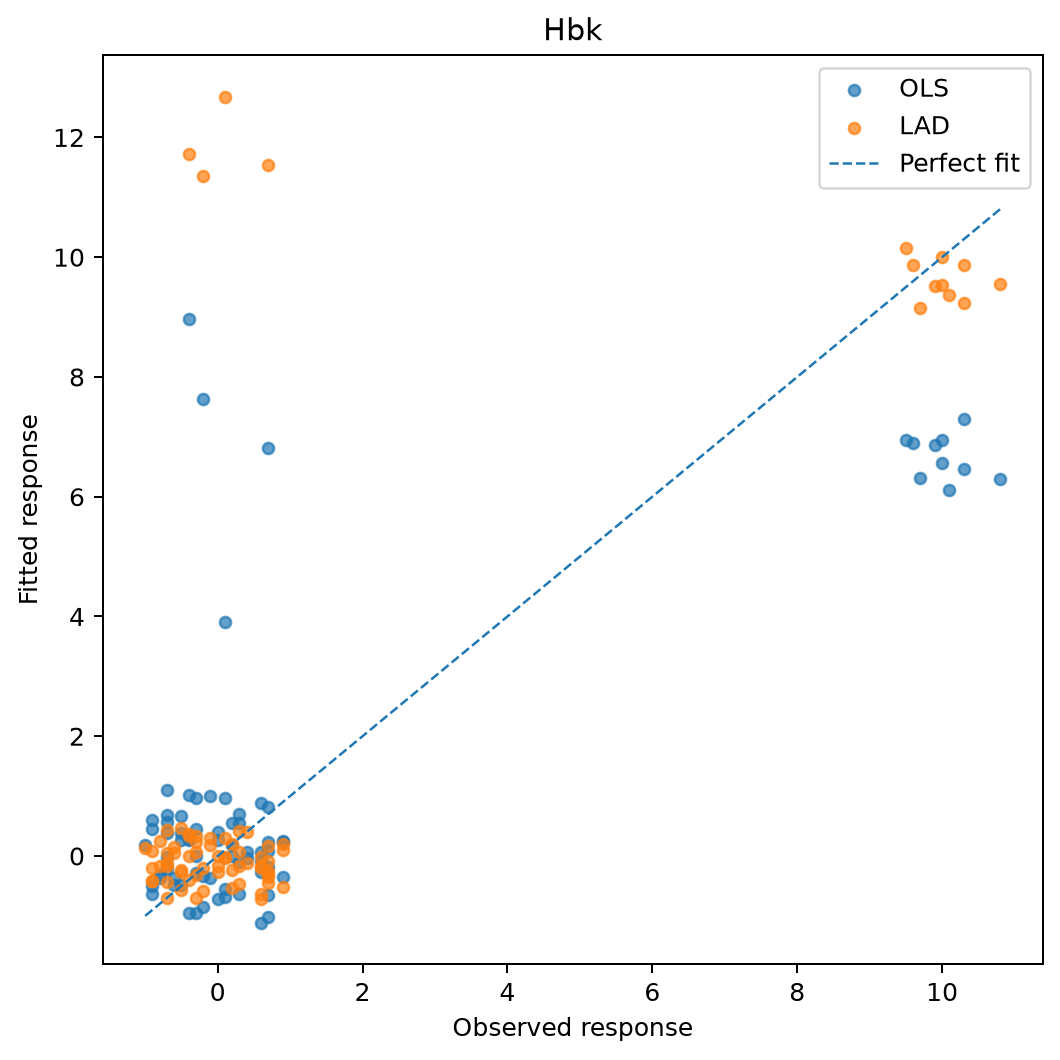

In [4]:
plot_real_dataset_predictions()
plot_hbk_multivariate_inlier_outlier()
plot_unlabeled_multivariate_residual_space("boston_housing", "Boston Housing")
plot_unlabeled_multivariate_residual_space("concrete_strength", "Concrete Strength")

for filename in [
    "hbk_multivariate_inlier_outlier.png",
    "boston_housing_multivariate_residuals.png",
    "concrete_strength_multivariate_residuals.png",
    "boston_housing_actual_vs_fitted.png",
    "concrete_strength_actual_vs_fitted.png",
    "hbk_actual_vs_fitted.png",
]:
    display(Image(filename=str(FIGURE_DIR / filename)))

## 5. Controlled large-response-error experiment

Large vertical response errors are introduced into a controlled regression design. The contamination fractions are project-selected illustration settings.


,contamination_fraction,model,MAE,RMSE
0,0.00,LAD,0.728317,0.954261
1,0.00,OLS,0.732734,0.949546
2,0.05,LAD,0.729197,0.954035
3,0.05,OLS,1.573396,1.953420
4,0.10,LAD,0.730924,0.954603
5,0.10,OLS,2.113013,2.598905
6,0.20,LAD,0.736783,0.958487
7,0.20,OLS,3.290895,4.015758


,contamination_fraction,model,coefficient_shift_l2,prediction_shift_mae
0,0.00,LAD,0.000000,0.000000
1,0.00,OLS,0.000000,0.000000
2,0.05,LAD,0.028853,0.022626
3,0.05,OLS,1.660385,1.344961
4,0.10,LAD,0.064670,0.050346
5,0.10,OLS,2.397969,1.958495
6,0.20,LAD,0.135968,0.107578
7,0.20,OLS,3.860536,3.186310


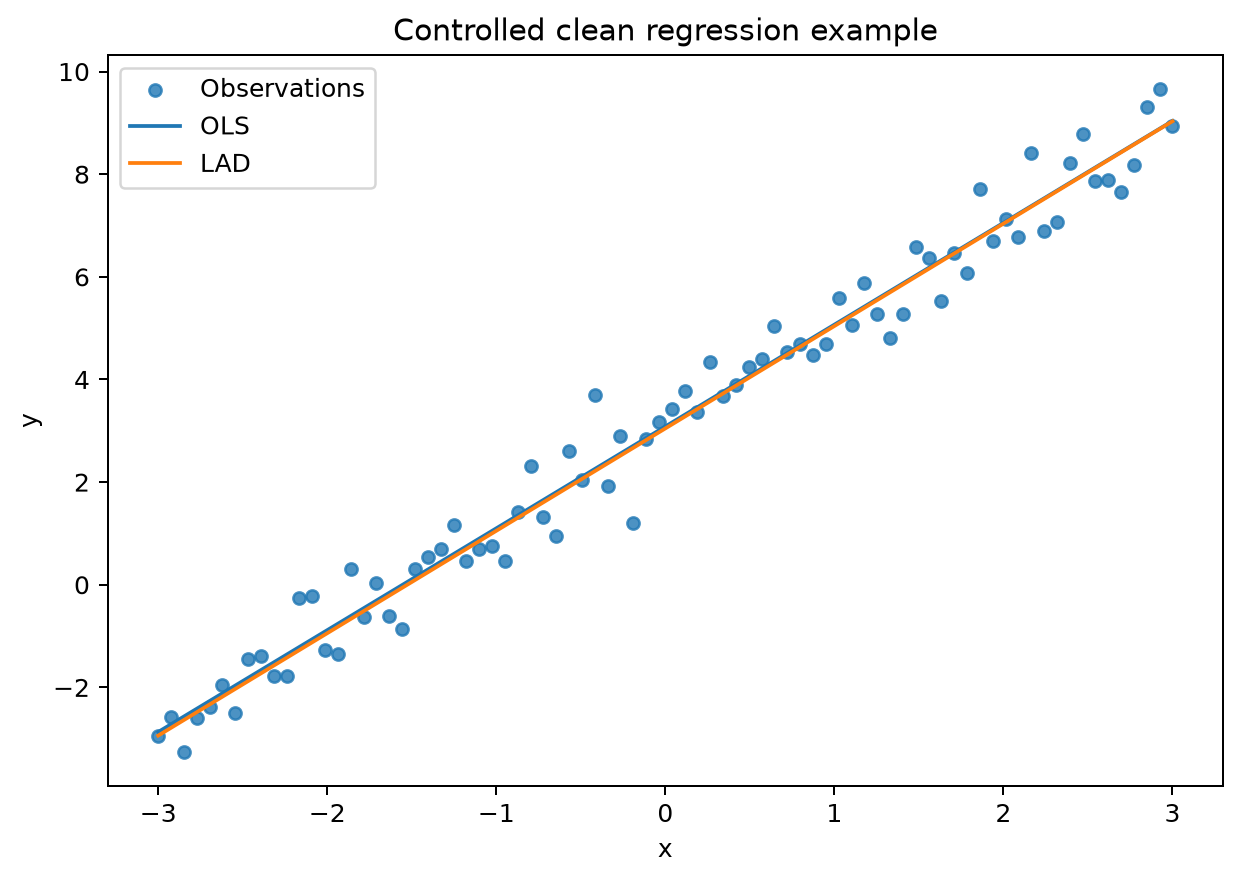

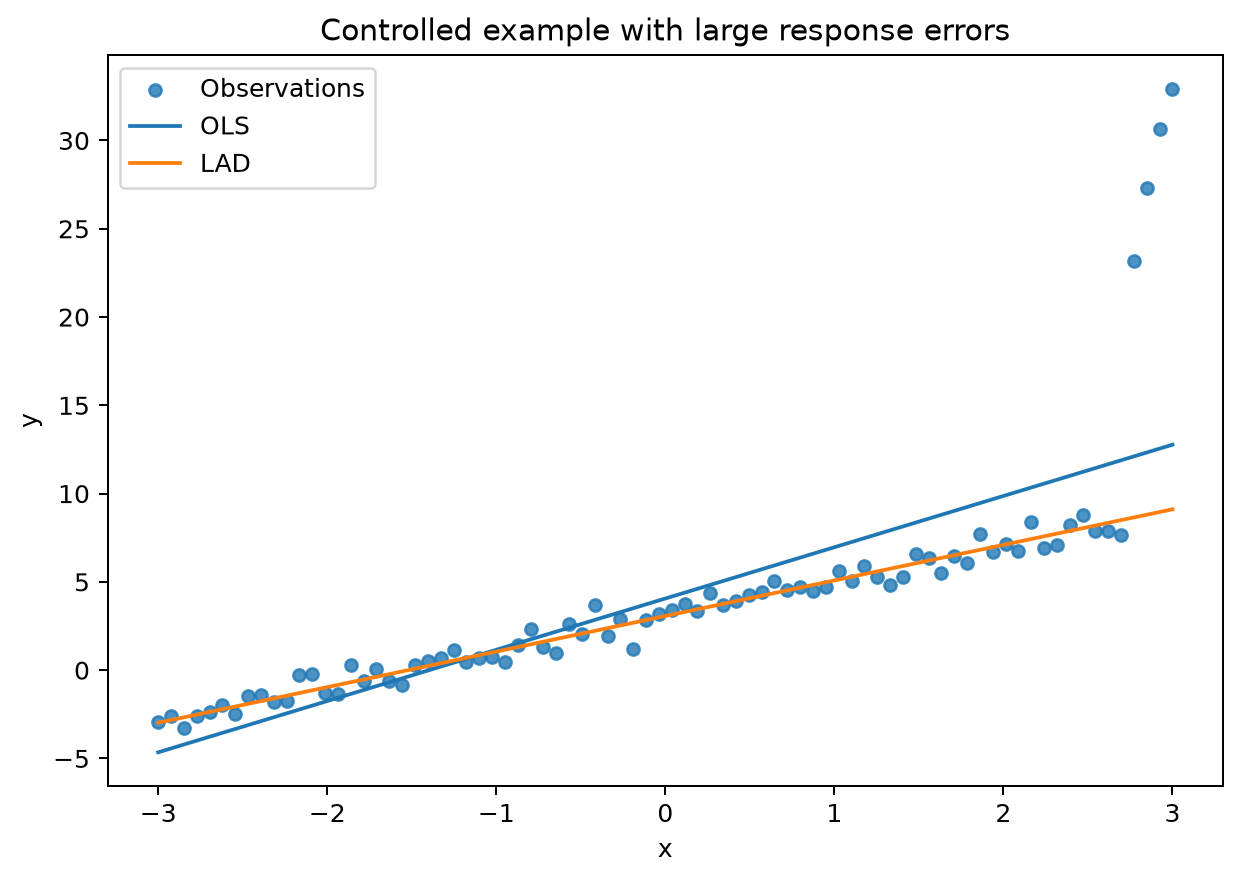

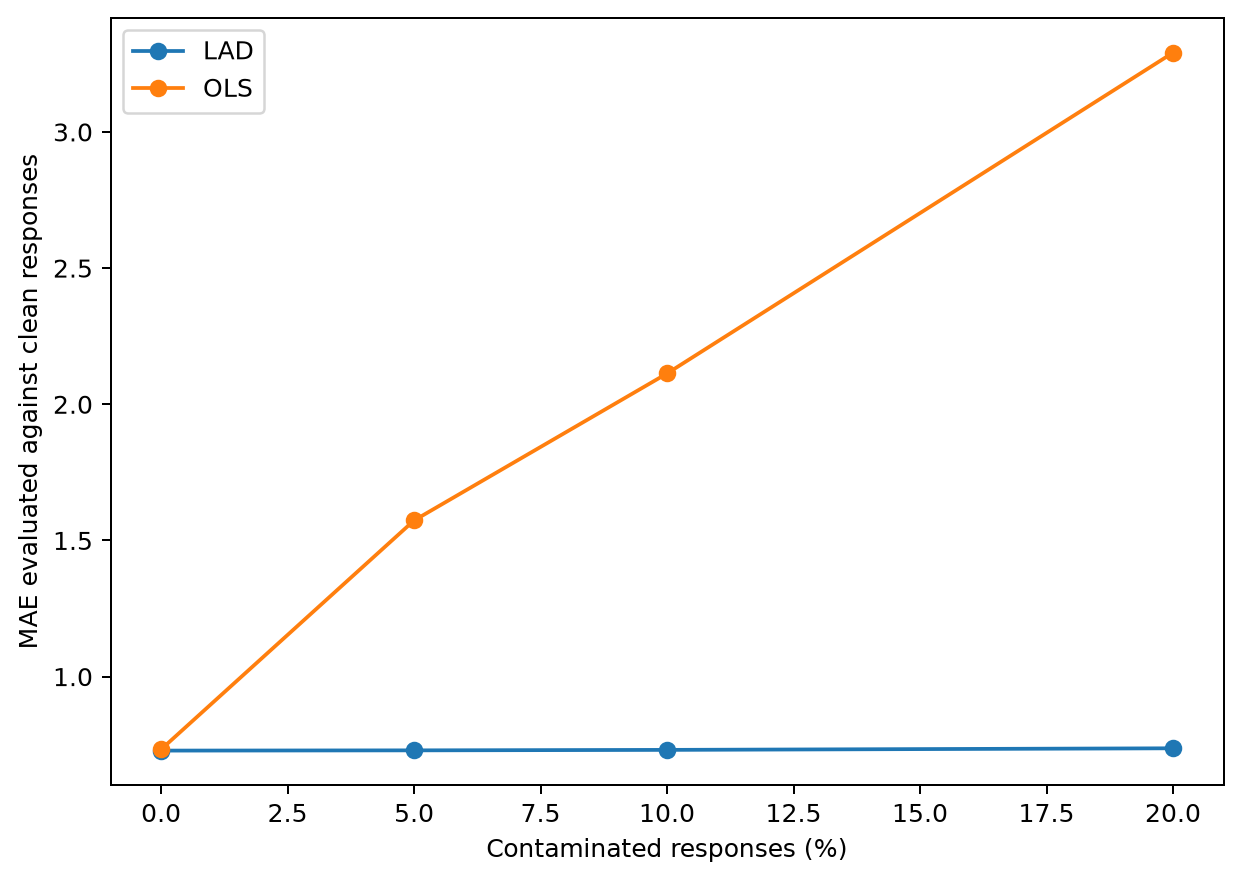

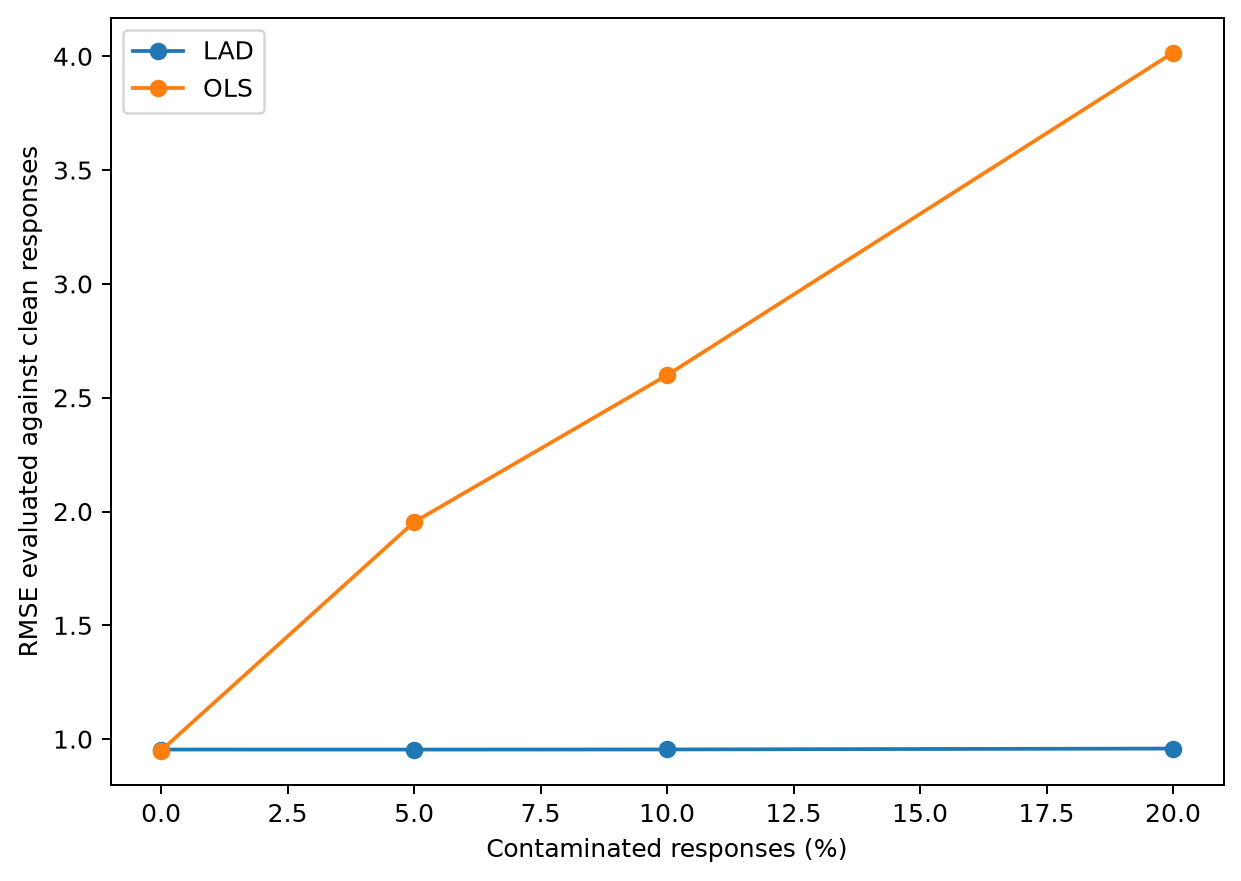

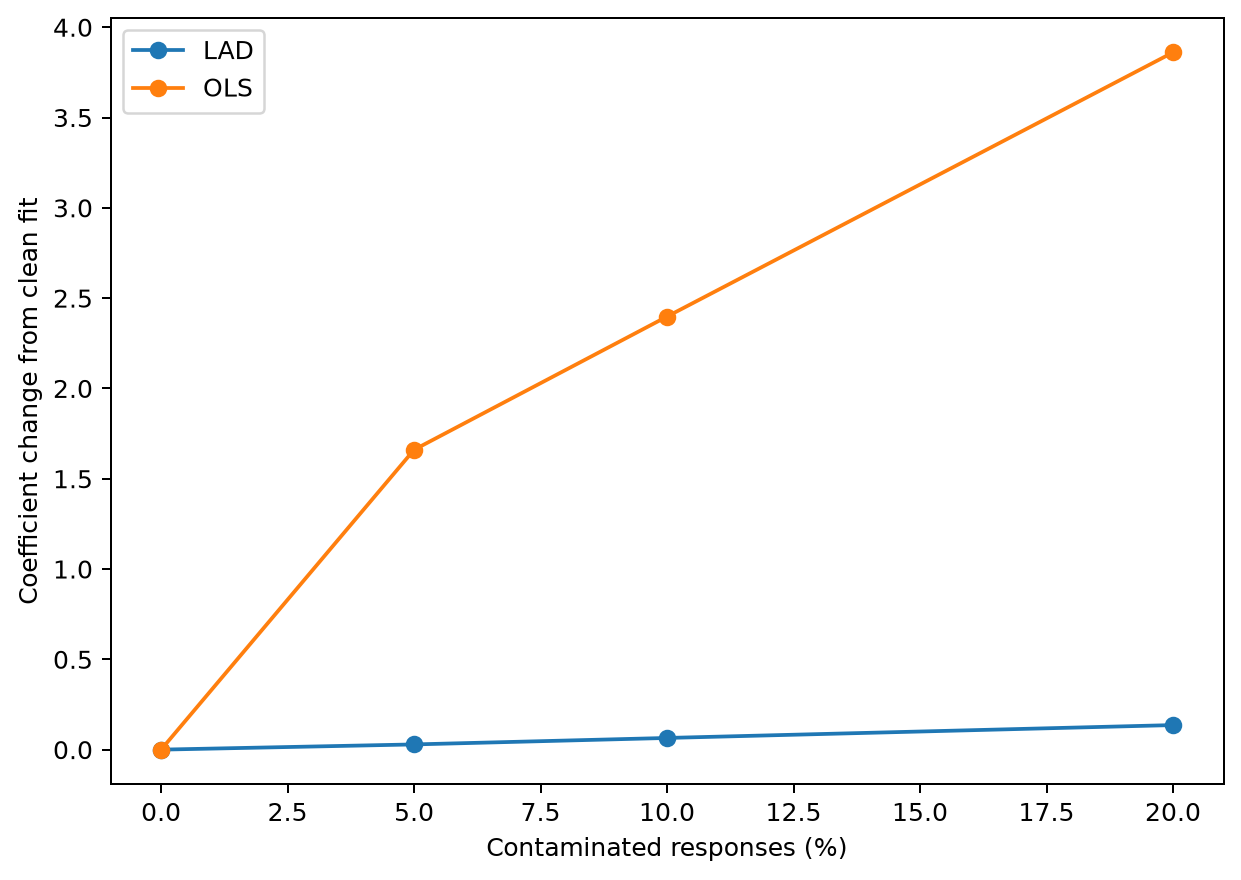

In [5]:
contamination_metrics, contamination_shifts = run_contamination_experiment()
plot_clean_and_contaminated_lines()
plot_contamination_results()

contamination_summary = (
    contamination_metrics
    .groupby(["contamination_fraction", "model"])[["MAE", "RMSE"]]
    .mean()
    .reset_index()
)
shift_summary = (
    contamination_shifts
    .groupby(["contamination_fraction", "model"])[["coefficient_shift_l2", "prediction_shift_mae"]]
    .mean()
    .reset_index()
)

display(contamination_summary)
display(shift_summary)

for filename in [
    "ols_lad_clean_fit.png",
    "ols_lad_contaminated_fit.png",
    "mae_vs_contamination.png",
    "rmse_vs_contamination.png",
    "coefficient_shift_vs_contamination.png",
]:
    display(Image(filename=str(FIGURE_DIR / filename)))

## 6. Error-distribution experiment

OLS and LAD are compared under Normal, Laplace, Cauchy, and contaminated-normal errors.


,distribution,model,coefficient_error_l2,SSE,SAE,MAE,RMSE
0,cauchy,LAD,0.267037,36618.163777,677.088736,4.513925,15.606881
1,cauchy,OLS,2.497144,35943.810534,830.185744,5.534572,15.463219
2,contaminated_normal,LAD,0.184862,1444.597511,216.386353,1.442576,3.103329
3,contaminated_normal,OLS,0.472607,1423.420948,224.566884,1.497113,3.080490
4,laplace,LAD,0.124388,143.129097,103.909445,0.692730,0.976828
5,laplace,OLS,0.162644,140.179326,105.021520,0.700143,0.966705
6,normal,LAD,0.186731,148.282634,117.174284,0.781162,0.994259
7,normal,OLS,0.153228,145.076526,117.773801,0.785159,0.983451


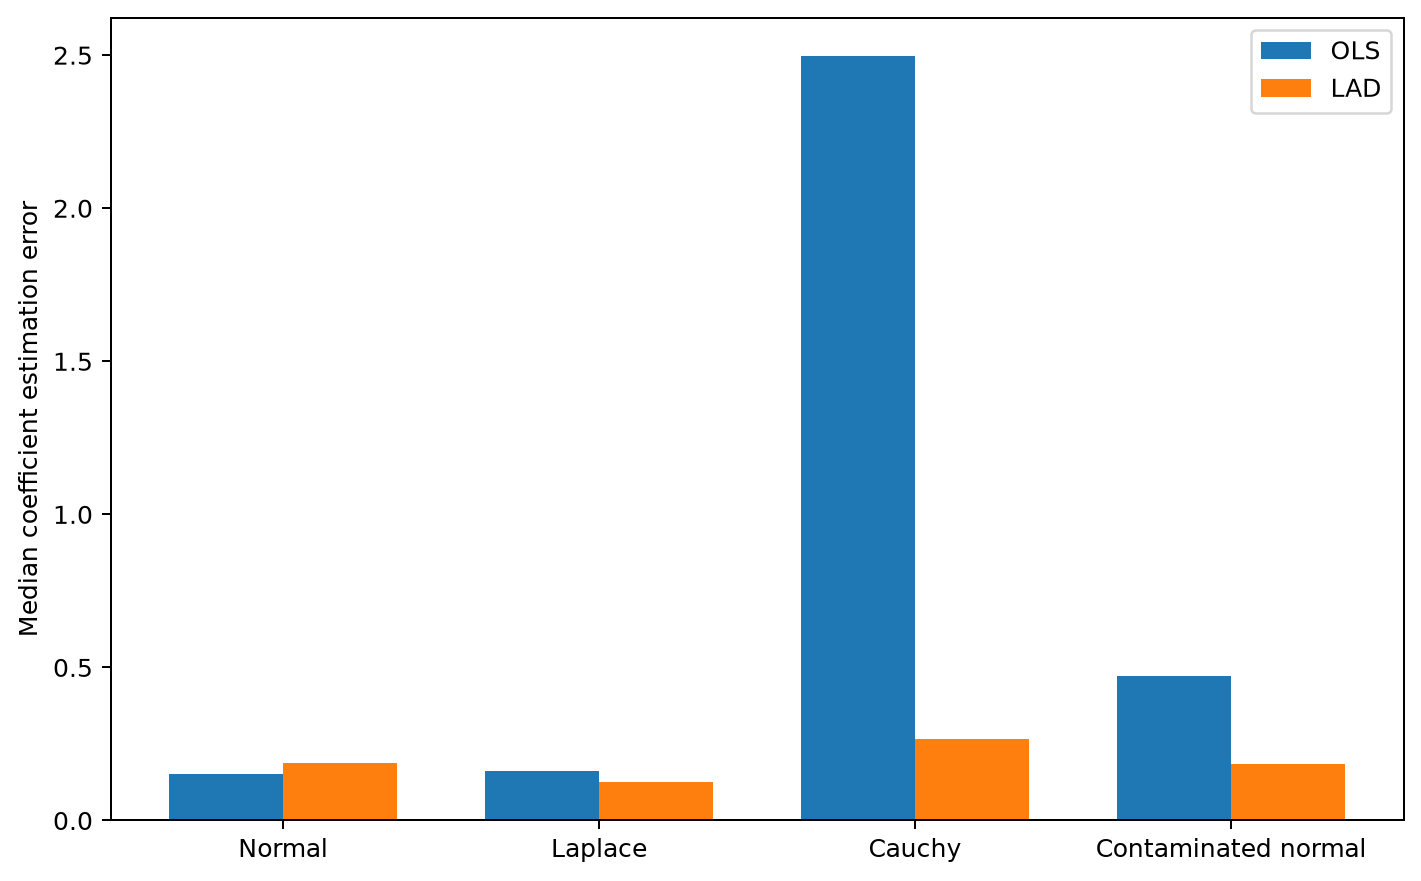

In [6]:
distribution_results = run_error_distribution_experiment()
plot_distribution_results()

distribution_summary = (
    distribution_results
    .groupby(["distribution", "model"])[["coefficient_error_l2", "SSE", "SAE", "MAE", "RMSE"]]
    .median()
    .reset_index()
)

display(distribution_summary)
display(Image(filename=str(FIGURE_DIR / "error_distribution_comparison.png")))

## 7. Computational comparison

,n,p,model,runtime_seconds
0,50,1,LAD,0.001850
1,50,1,OLS,0.000073
2,50,3,LAD,0.001954
3,50,3,OLS,0.000046
4,50,5,LAD,0.002070
5,50,5,OLS,0.000052
6,100,1,LAD,0.002810
7,100,1,OLS,0.000040
8,100,3,LAD,0.003016
9,100,3,OLS,0.000047


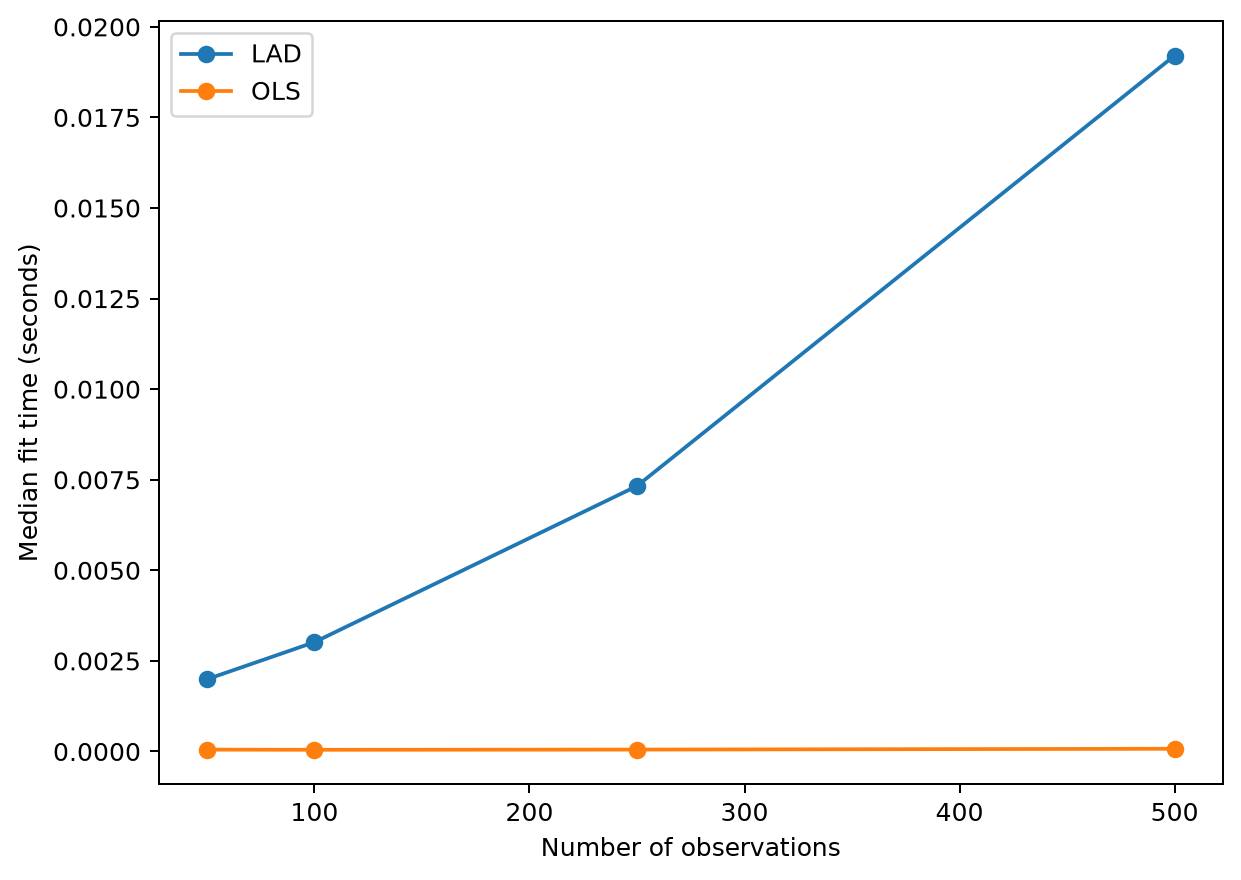

In [7]:
runtime_results = run_runtime_benchmark()
plot_runtime_results()

runtime_summary = (
    runtime_results
    .groupby(["n", "p", "model"])["runtime_seconds"]
    .median()
    .reset_index()
)

display(runtime_summary)
display(Image(filename=str(FIGURE_DIR / "runtime_vs_sample_size.png")))

## 8. Solver validation

For deterministic examples, the OLS solution must have SSE no larger than the SSE at the LAD coefficients, and the LAD solution must have SAE no larger than the SAE at the OLS coefficients.


In [8]:
validation = validate_lad_solver()
display(validation)

assert validation["ols_sse_is_minimum_against_lad"].all()
assert validation["lad_sae_is_minimum_against_ols"].all()

print("All OLS/LAD objective checks passed.")

,example,ols_sse,lad_sse,ols_sae,lad_sae,ols_sse_is_minimum_against_lad,lad_sae_is_minimum_against_ols
0,1,3.621429e+02,676.0,4.085714e+01,26.0,True,True
1,2,9.860761e-32,0.0,4.440892e-16,0.0,True,True


All OLS/LAD objective checks passed.


## 9. Generated outputs

In [9]:
result_files = sorted(path.name for path in RESULT_DIR.glob("*.csv"))
figure_files = sorted(path.name for path in FIGURE_DIR.glob("*.png"))

print("Result files:")
for name in result_files:
    print(" -", name)

print("\nFigure files:")
for name in figure_files:
    print(" -", name)

Result files:
 - contamination_coefficient_changes.csv
 - contamination_metrics.csv
 - distribution_experiment.csv
 - lad_solver_validation.csv
 - original_data_coefficients.csv
 - original_data_metrics.csv
 - runtime_results.csv

Figure files:
 - boston_housing_actual_vs_fitted.png
 - boston_housing_multivariate_residuals.png
 - coefficient_shift_vs_contamination.png
 - concrete_strength_actual_vs_fitted.png
 - concrete_strength_multivariate_residuals.png
 - error_distribution_comparison.png
 - hbk_actual_vs_fitted.png
 - hbk_multivariate_inlier_outlier.png
 - mae_vs_contamination.png
 - ols_lad_clean_fit.png
 - ols_lad_contaminated_fit.png
 - rmse_vs_contamination.png
 - runtime_vs_sample_size.png


## 10. Conclusion

The workflow compares squared-loss and absolute-loss regression on the same empirical data and under controlled large-error and long-tailed settings. OLS directly minimizes squared residuals, while LAD directly minimizes absolute residuals. The project therefore treats their differences as consequences of the loss function and error behavior rather than claiming that either estimator is universally superior.
